**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRE: Eduardo Miguel Paz Calvopiña
*   MATRÍCULA: A00886517

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MIAA/8.1 Aprende | Aprendizaje supervisado/Actividad 8"
os.chdir(DIR)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
insurance_df = pd.read_csv('insurance.csv')
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **Parte 1**. EDA

Efectúa una exploración inicial de los datos a través de:

1a) Estadísticas descriptivas para todas las variables del dataframe.

In [5]:
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
print("\n--- Estadísticas Descriptivas (Numéricas) ---")
display(insurance_df.describe().T)


--- Estadísticas Descriptivas (Numéricas) ---


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [7]:
# Estadísticas para variables categóricas
print("\n--- Estadísticas Descriptivas (Categóricas) ---")
display(insurance_df.describe(include=['object']).T)


--- Estadísticas Descriptivas (Categóricas) ---


,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


1b) Búsqueda de valores faltantes.

In [8]:
print(insurance_df.isna().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


1c) Histrogramas y boxplots para las variables cuantitativas y diagramas de barras con la frecuencia para las variables categóricas.

In [9]:
# Variables numéricas
num_cols = ['age', 'bmi', 'children', 'charges']

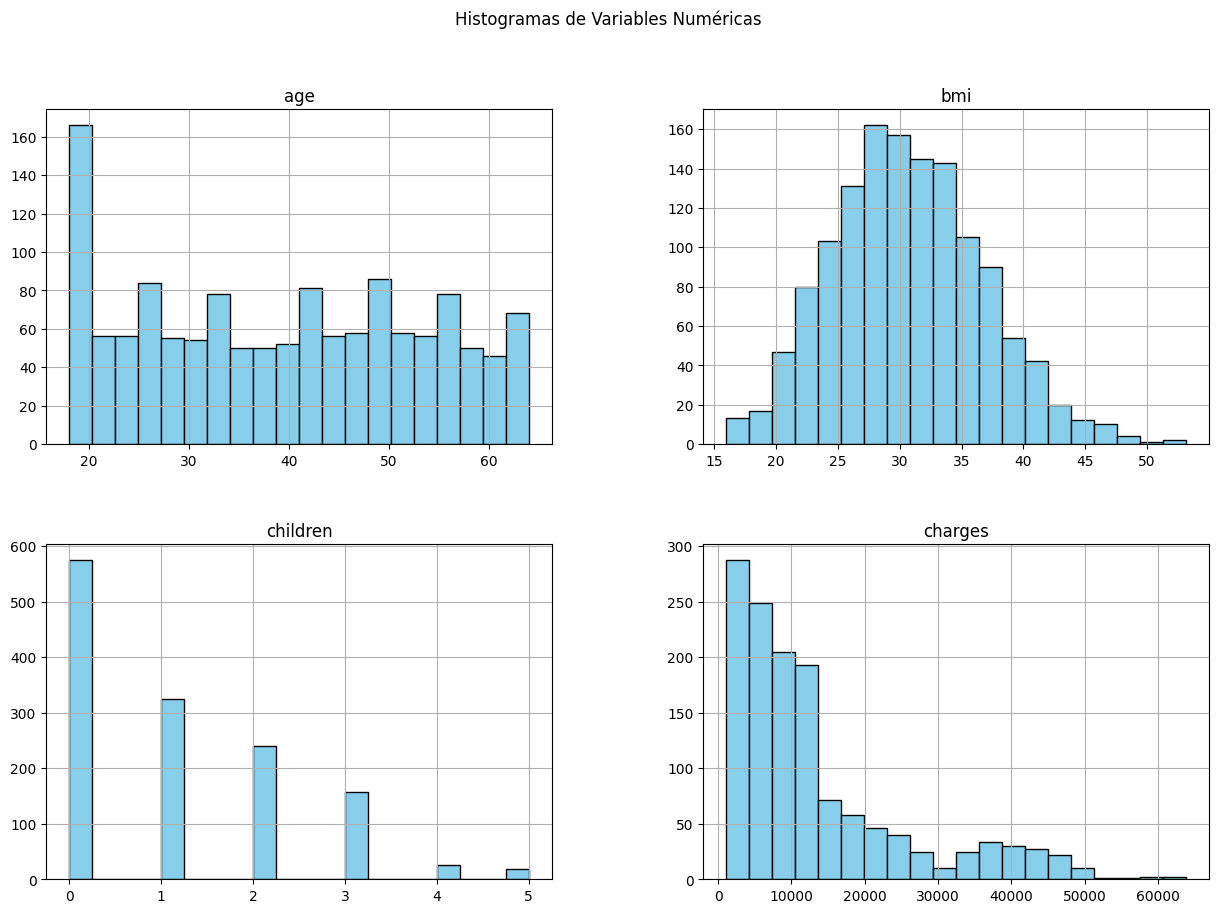

In [10]:
# Histogramas para ver la distribución
insurance_df[num_cols].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histogramas de Variables Numéricas')
plt.show()

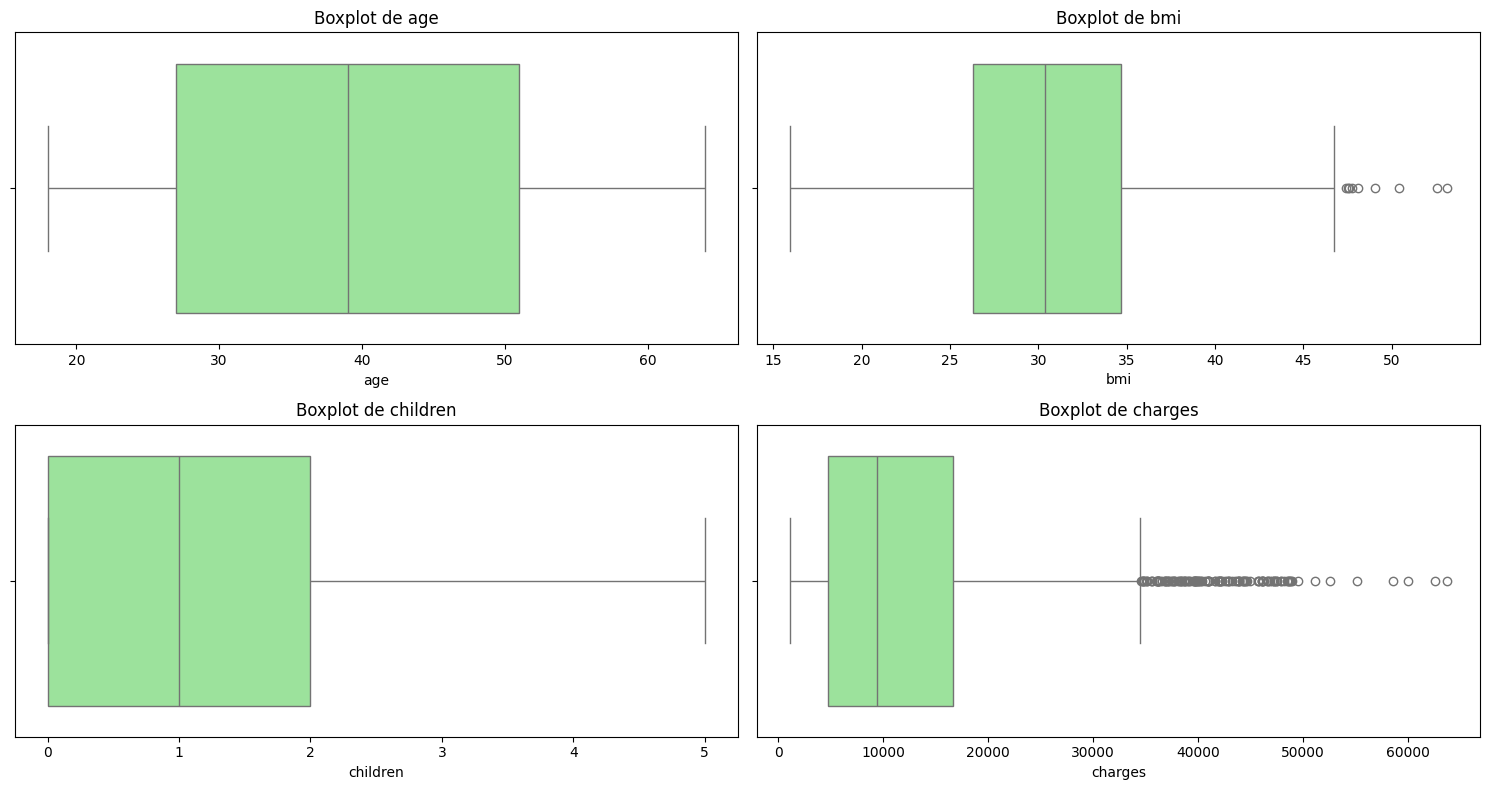

In [11]:
# Boxplots  (outliers)
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=insurance_df[col], color='lightgreen')
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

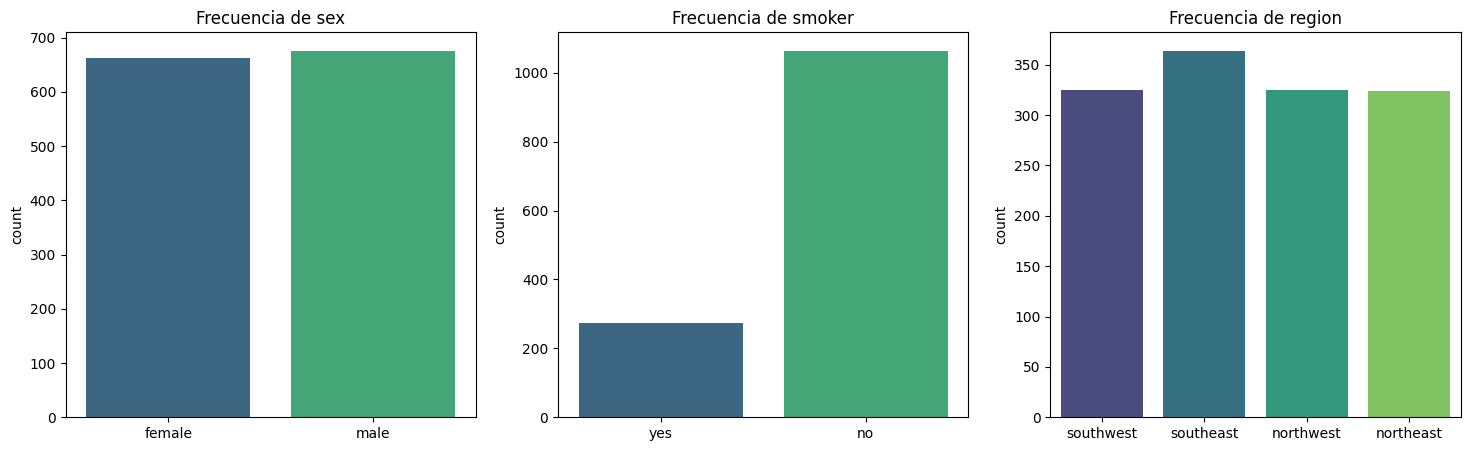

In [12]:
# Variables categóricas
cat_cols = ['sex', 'smoker', 'region']

# Gráficos de barras para frecuencias
plt.figure(figsize=(18, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    # Agregamos hue=insurance_df[col] y legend=False para cumplir con la nueva sintaxis
    sns.countplot(x=insurance_df[col], hue=insurance_df[col], palette='viridis', legend=False)
    plt.title(f'Frecuencia de {col}')
    plt.xlabel(None)
plt.show()

Para responder los siguientes cuestionamientos, genera los gráficos indicados:

2a) ¿Hay diferencias significativas de las primas según el sexo? Compara la distribución de la variable `charges` por medio de un boxplot.

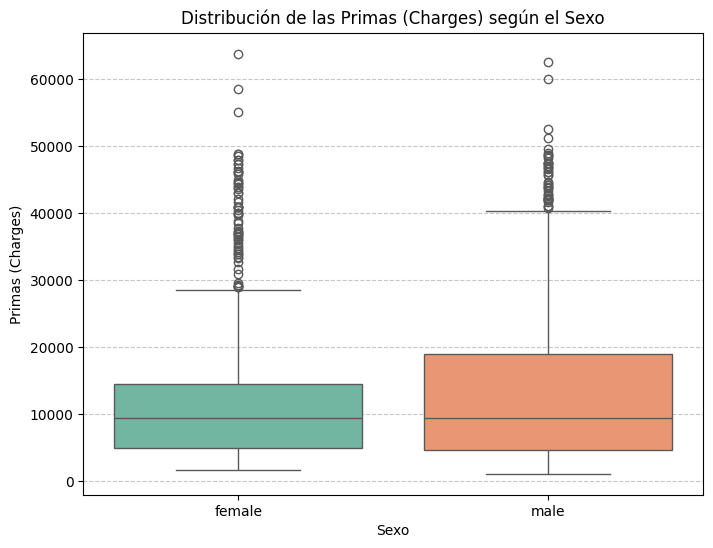

In [13]:
plt.figure(figsize=(8, 6))

# Boxplot charges por sexo
sns.boxplot(x='sex', y='charges', data=insurance_df, hue='sex', palette='Set2', legend=False)
plt.title('Distribución de las Primas (Charges) según el Sexo')
plt.xlabel('Sexo')
plt.ylabel('Primas (Charges)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**RESPUESTA:** Aunque el costo mediano es similar entre sexos, existen diferencias en la distribución y dispersión, ya que el grupo masculino presenta una mayor variabilidad y un desplazamiento hacia costos más altos de seguro

2b) Crea un diagrama de dispersión de `charges` versus el `bmi` que incorpore la distinción por las categorías `smoker` y `children` (tip: utiliza el parámetro `size`) ¿Hay alguna conclusión importante que se derive del gráfico?

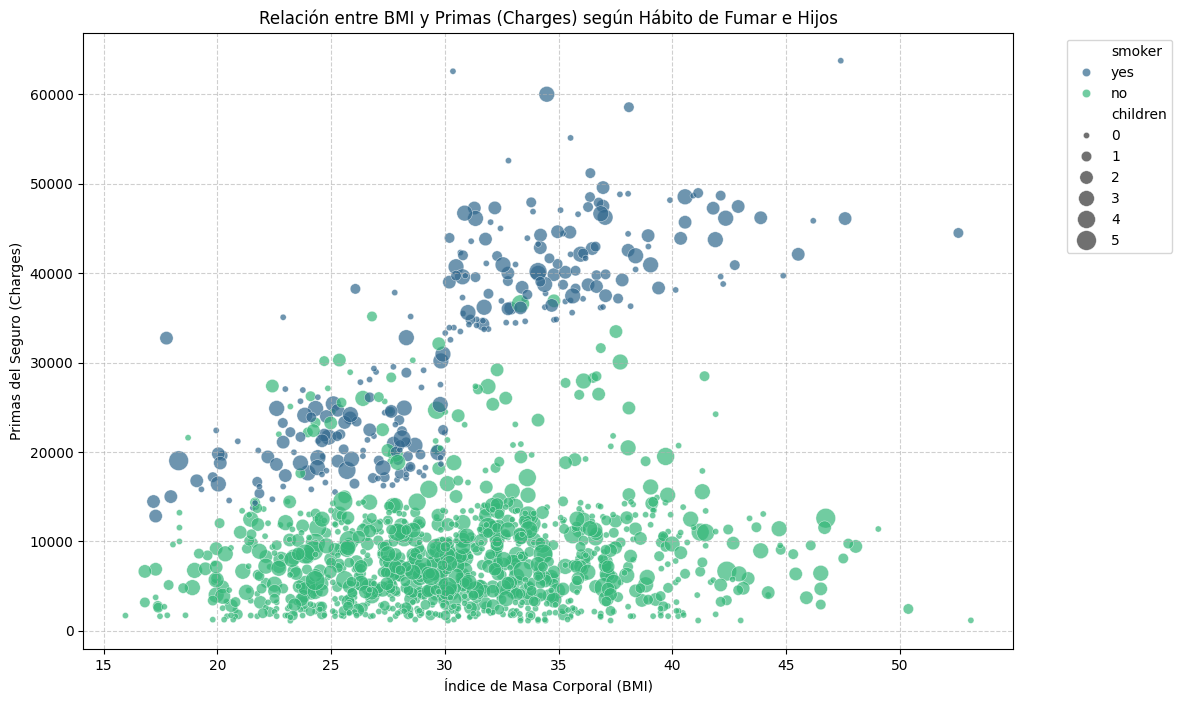

In [14]:
plt.figure(figsize=(12, 8))

# Diagrama de dispersión
sns.scatterplot(x='bmi', y='charges', data=insurance_df,
                hue='smoker', size='children',
                palette='viridis', alpha=0.7, sizes=(20, 200))

plt.title('Relación entre BMI y Primas (Charges) según Hábito de Fumar e Hijos')
plt.xlabel('Índice de Masa Corporal (BMI)')
plt.ylabel('Primas del Seguro (Charges)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**RESPUESTA:** Un factor que hace que la prima se eleve de manera muy clara es el hecho de que la persona sea fumador. Otro factor importante es el BMI, la prima aumenta a medida de que su BMI aumenta, sin embargo, esto se visualiza más con los fumadores. No veo una relación con el número de hijos.

2c) Elabora un mapa de calor que muestre la correlación de las variables numéricas.

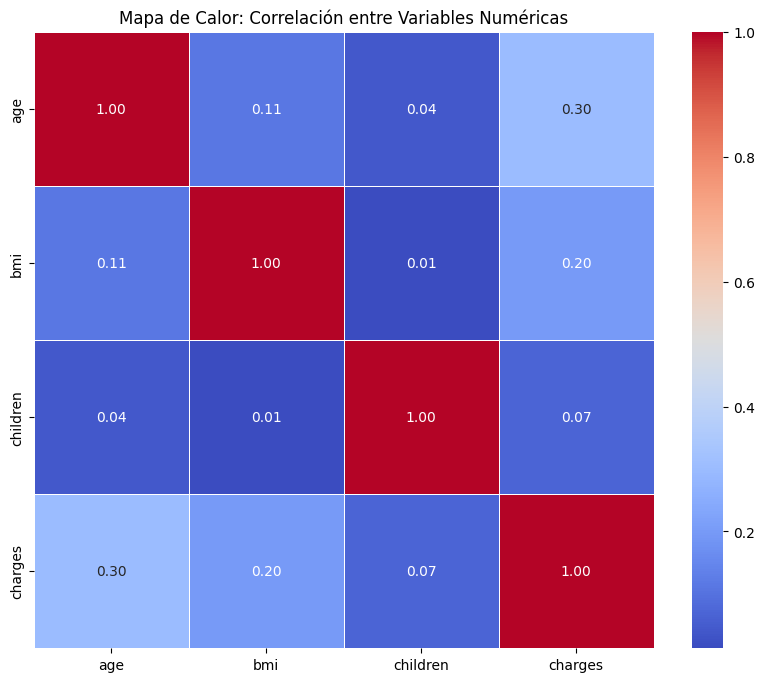

In [15]:
correlation_matrix = insurance_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))

# Mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación entre Variables Numéricas')
plt.show()

Obtén un dataframe con las observaciones que tengan valores atípicos en `charges`.

3a) ¿Cuál es el promedio de `age` y de `bmi` en el dataframe de valores atípicos obtenido?

In [16]:
#Cálculos
Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [17]:
# Dataframe con los valores atípicos
outliers_df = insurance_df[(insurance_df['charges'] < limite_inferior) |
                           (insurance_df['charges'] > limite_superior)]

In [18]:
promedio_age = outliers_df['age'].mean()
promedio_bmi = outliers_df['bmi'].mean()

print(f"Número de valores atípicos: {len(outliers_df)}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"\nPromedio de edad: {promedio_age:.2f} años")
print(f"Promedio de BMI: {promedio_bmi:.2f}")

outliers_df.head()

Número de valores atípicos: 139
Límite superior: 34489.35

Promedio de edad: 41.08 años
Promedio de BMI: 35.56


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


3b) ¿Qué porcentaje de estas observaciones (en el dataframe de valores atípicos obtenidos) se corresponden a mujeres y a hombres? ¿A fumadores y no fumadores?

In [19]:
# 1. Calculo porcentajes para la variable 'sex' (mujeres y hombres)
porcentaje_sexo = outliers_df['sex'].value_counts(normalize=True).multiply(100)

# 2. Calculo porcentajes para la variable 'smoker' (fumadores y no fumadores)
porcentaje_fumador = outliers_df['smoker'].value_counts(normalize=True).multiply(100)

print("\nPorcentaje por Sexo:")
print(porcentaje_sexo.apply(lambda x: f'{x:,.2f}%').to_string())

print("\nPorcentaje fumadores:")
print(porcentaje_fumador.apply(lambda x: f'{x:,.2f}%').to_string())


Porcentaje por Sexo:
sex
male      64.03%
female    35.97%

Porcentaje fumadores:
smoker
yes    97.84%
no      2.16%


# **Parte 2**. Preprocesamiento

4. Separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`charges`).

In [20]:
# Separar predictores (X) y variable objetivo (y)
X = insurance_df.drop(columns=['charges'])
y = insurance_df['charges']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1338, 6)
Dimensiones de y: (1338,)


5. Divide el conjunto en entrenamiento y prueba (80:20) considerando:


*   El parámetro `random_state` con el valor de 1 para garantizar reproducibilidad.
*   Analiza los diagramas de barras obtenidos en el ejercicio 1c. Con los resultados observados, es conveniente usar la variable `smoker` en la estrategia de estratificación.
*   Como ya tienes separadas en `X` e `y` los predictores y salida, consulta cómo ejecutar la función `train_test_split()` para obtener `Xtrain, Xtest, ytrain, ytest` en una única instrucción.

In [21]:
from sklearn.model_selection import train_test_split

# Paso 5: División 80:20 con random_state=1 y estratificación por fumador
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=1,
    stratify=X['smoker']
)

print(f"Registros en entrenamiento: {len(X_train)}")
print(f"Registros en prueba: {len(X_test)}")

Registros en entrenamiento: 1070
Registros en prueba: 268


6. Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento *MinMax* a los predictores numéricos y codificación *one-hot* a los categóricas.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# Preprocessing
preprocessing = ColumnTransformer(transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)])


# **Parte 3**. Entrenando y evaluando el modelo de RL

7. Ejecuta un pipeline con el transformador creado y el algoritmo de regresión lineal para entrenar un modelo denominado `lr_model`.

Evalúa el modelo en el conjunto de prueba y obtén la raíz del error cuadrático medio (`RMSE`) y la métrica `R` cuadrado ($R^2$). Aunque ésta última la estudiarás a detalle la próxima semana, ahora sólo debes saber que toma valores entre 0 y 1, donde 1 indica un ajuste perfecto y, por tanto, un modelo muy fiable para las previsiones futuras. La función de scikit-learn que determina esta métrica es: [`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Pipeline (preprocesamiento y el modelo)
lr_model = Pipeline(steps=[
    ('prep', preprocessing),
    ('regressor', LinearRegression())])

# Entrenar el modelo / Predicciones
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# Evaluación del desempeño (RMSE y R²)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Evaluación del Modelo ---")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

--- Evaluación del Modelo ---
RMSE: 5698.76
R²: 0.7539


**Valora el rendimiento del modelo con los siguientes cambios:**


8. Reemplaza los outliers de `charges` con el límite superior (`Q3 + 1.5 * IQR`). Haz el cambio en ambos conjuntos: `ytrain` y `ytest`, previo a la aplicación del mismo pipeline. Guarda el modelo como `lr_model2`.


In [24]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

In [25]:
# Cambio en y_train y y_test (reemplazo con límite superior)
y_train_clipped = y_train.clip(upper=limite_superior)
y_test_clipped = y_test.clip(upper=limite_superior)

In [26]:
# Nuevo modelo 'lr_model2' usando el MISMO pipeline
from sklearn.pipeline import clone
lr_model2 = clone(lr_model)

lr_model2.fit(X_train, y_train_clipped)
y_pred2 = lr_model2.predict(X_test)
rmse2 = root_mean_squared_error(y_test_clipped, y_pred2)
r2_2 = r2_score(y_test_clipped, y_pred2)

print(f"--- Evaluación del Modelo con Reemplazo de Outliers (lr_model2) ---")
print(f"Límite superior aplicado: {limite_superior:.2f}")
print(f"Nuevo RMSE: {rmse2:.2f}")
print(f"Nuevo R²: {r2_2:.4f}")

# Comparación rápida con el modelo anterior
print(f"\nComparación R²: Modelo 1 ({r2:.4f}) vs Modelo 2 ({r2_2:.4f})")

--- Evaluación del Modelo con Reemplazo de Outliers (lr_model2) ---
Límite superior aplicado: 35861.97
Nuevo RMSE: 4995.03
Nuevo R²: 0.7606

Comparación R²: Modelo 1 (0.7539) vs Modelo 2 (0.7606)


9. Prepara otro transformador, denominado `preprocessing2`, para aplicar escalamiento estándar a los predictores numéricos y codificación ordinal a los categóricas. Aplícalo en un nuevo pipeline utilizando nuevamente regresión lineal. Guarda el modelo como `lr_model3`.

**Nota.** Los cambios se ejecutan de manera consecutiva, por ejemplo: el reemplazo de los outliers también se ejecuta previo al transformador `preprocessing2` y así sucesivamente.

In [27]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

preprocessing2 = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), cat_cols)])

lr_model3 = Pipeline(steps=[
    ('prep', preprocessing2),
    ('regressor', LinearRegression())])


lr_model3.fit(X_train, y_train_clipped)
y_pred3 = lr_model3.predict(X_test)
rmse3 = root_mean_squared_error(y_test_clipped, y_pred3)
r2_3 = r2_score(y_test_clipped, y_pred3)

print("--- Evaluación del Modelo con Nuevo Preprocesamiento (lr_model3) ---")
print(f"RMSE: {rmse3:.2f}")
print(f"R²: {r2_3:.4f}")

# Comparación con los modelos previos
print(f"\nComparativa de R²:")
print(f"Modelo 1 (Base): {r2:.4f}")
print(f"Modelo 2 (Clipping): {r2_2:.4f}")
print(f"Modelo 3 (Standard + Ordinal): {r2_3:.4f}")

--- Evaluación del Modelo con Nuevo Preprocesamiento (lr_model3) ---
RMSE: 4994.26
R²: 0.7606

Comparativa de R²:
Modelo 1 (Base): 0.7539
Modelo 2 (Clipping): 0.7606
Modelo 3 (Standard + Ordinal): 0.7606


10. Utiliza regresión polinomial para verificar si se produce un mejor ajuste. Intenta con varios grados, aunque debes dejar en el código sólo el de mejor rendimiento. Guarda el modelo como `lr_model4`.

In [28]:
# Grado del polinomio
grado_polinomio = 2

In [29]:
from sklearn.preprocessing import PolynomialFeatures

lr_model4 = Pipeline(steps=[
    ('prep', preprocessing2),
    ('poly', PolynomialFeatures(degree=grado_polinomio)),
    ('regressor', LinearRegression())])

lr_model4.fit(X_train, y_train_clipped)
y_pred4 = lr_model4.predict(X_test)
rmse4 = root_mean_squared_error(y_test_clipped, y_pred4)
r2_4 = r2_score(y_test_clipped, y_pred4)
print(f"--- Evaluación del Modelo Polinomial (lr_model4 - Grado {grado_polinomio}) ---")
print(f"RMSE final: {rmse4:.2f}")
print(f"R² final: {r2_4:.4f}")

# Comparativa final de todos los modelos
print(f"\nResumen de Desempeño (R²):")
print(f"Modelo 1 (Base): {r2:.4f}")
print(f"Modelo 2 (Clipping): {r2_2:.4f}")
print(f"Modelo 3 (Std+Ord): {r2_3:.4f}")
print(f"Modelo 4 (Polinomial): {r2_4:.4f}")

--- Evaluación del Modelo Polinomial (lr_model4 - Grado 2) ---
RMSE final: 4384.47
R² final: 0.8155

Resumen de Desempeño (R²):
Modelo 1 (Base): 0.7539
Modelo 2 (Clipping): 0.7606
Modelo 3 (Std+Ord): 0.7606
Modelo 4 (Polinomial): 0.8155
